# Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
file_path = '../data/raw_sweeps' # add path to data 

from utils import update_rc_params

In [2]:
from sweep import sweep_load as sl
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline

from matplotlib.gridspec import GridSpec
from matplotlib.gridspec import GridSpec

import sys
sys.path.append("../utils")
from utils import *

In [3]:
update_rc_params('talk')

# nD map hole SC

In [4]:
def plot_nD_map(fig, ax, norm, cmap, contact_id=5):
    files = [971]

    contact_pairs = {
    'long1': {'indices': [contact_id], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }

    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
    
        for ind in indices:
            for file in files:
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                xs = data['xs'] # top gate
                ys = data['ys'] # back gate
                phase = data[f'sr830_{ind}_P']
    
                I = data['sr830_4_X']
                Vxx = data[f'sr830_{ind}_X']
                zs = Vxx / I
    
                Vbg = np.matlib.repmat(ys, len(xs), 1).T
                Vtg = np.matlib.repmat(xs, len(ys), 1)
                finite = np.isfinite(I)
                mask = np.abs(I) < 0.7 * np.nanmax(I)
                zs_m = np.ma.array(zs, mask=mask | ~finite)
                
                xs, ys = calculate_n_D(Vbg, Vtg, dtg=16, dbg=25.5)
                plot = ax.pcolormesh(xs, ys, zs_m, norm=norm, cmap=cmap, rasterized=True, lw=0)
  
                ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
                ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
                ax.xaxis.set_major_locator(plt.MaxNLocator(6))
                ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot

<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_798242/3523913247.py:13: SyntaxWarning: invalid escape sequence '\O'
  cb.ax.annotate('$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',


['/home/aaron/Fermiology-and-the-cCSC/figs/hole-sc-map.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/hole-sc-map.png']

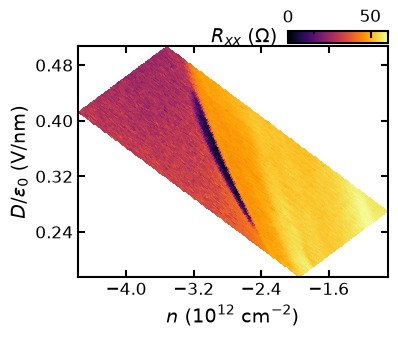

In [5]:
fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=25, vmin=0, vmax=0.1E3)
plot = plot_nD_map(fig, ax, norm, "inferno", contact_id=1)

pos = ax.get_position()
cb_width = 0.25  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.04])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 50], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$50$'])
cb.ax.annotate('$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  
save_fig(fig, 'hole-sc-map')

# T-Idc map

In [6]:
def plot_sc_dome(fig, ax, norm, cmap, contact_id=5):
    files = range(296, 425)
    contact_pairs = {
        'long1': {'indices': [contact_id], 'norm': norm, 'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
    
        for j, ind in enumerate(indices):       
            Ts = []
            inds = []
            Rxxs = []
            for i, file in enumerate(files):
                # load in the new data
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                xs = data['xs']*10 # bias in nA
                I = data['sr830_4_X']
                Vxx = data[f'sr830_{ind}_X']
                Rxx = Vxx / I
                T = np.mean(data['T'])
                inds.append(i)
                Ts.append(np.round(T,3))
                Rxxs.append(Rxx)
    
        vs = np.linspace(0, 3, len(Ts))
        T0 = 36.5
        Tcalc = T0 + 15.6*np.power(vs, 1.95)  
        plot = ax.pcolormesh(xs, Tcalc, Rxxs, norm=norm, cmap=cmap,rasterized=True, lw=0)
        ax.set_ylabel(r'$T$ (mK)')
        ax.set_xlabel(r'$I_{\mathrm{dc}}$ (nA)')
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))
        ax.yaxis.set_major_locator(plt.MaxNLocator(5))
    return plot

<>:13: SyntaxWarning: invalid escape sequence '\O'
<>:13: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_798242/2584291933.py:13: SyntaxWarning: invalid escape sequence '\O'
  cb.ax.annotate('$dV/dI$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',


['/home/aaron/Fermiology-and-the-cCSC/figs/hole-sc-temp.pdf',
 '/home/aaron/Fermiology-and-the-cCSC/figs/hole-sc-temp.png']

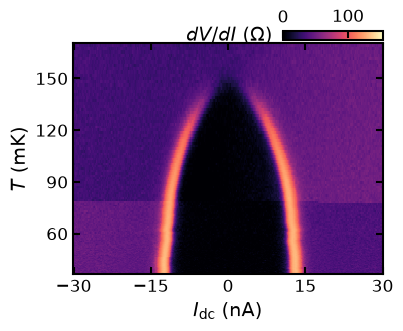

In [7]:
fig = plt.figure(figsize=(4,3))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=400)
plot = plot_sc_dome(fig, ax, norm, "magma")

pos = ax.get_position()
cb_width = 0.25  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.03])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$100$'])
cb.ax.annotate('$dV/dI$ ($\Omega$)', xy=(-0.10, 0.5), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  
save_fig(fig, 'hole-sc-temp')

# Full figure

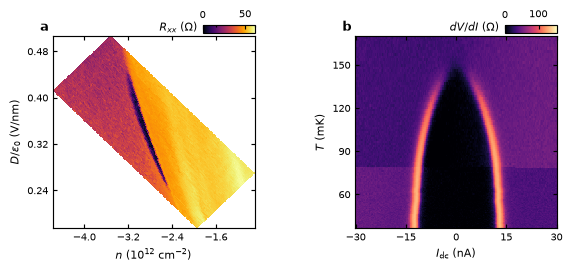

/tmp/ipykernel_798242/341565659.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [8]:
update_rc_params('paper')  # paper style for this final figure

# ── Global colorbar geometry ──────────────────────────────────────────────────
cb_width = 0.08          # colorbar width in figure fraction
cb_height_inches = 0.08  # colorbar height in physical inches (fixed across fig sizes)
# ─────────────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(6.5, 2.5))
gs = GridSpec(1, 2, figure=fig,   
                       width_ratios=[1, 1],
                       height_ratios=[1],
                       hspace=0.5, wspace=0.5)

cb_height_frac = cb_height_inches / fig.get_size_inches()[1]

################ Panel a ##################
ax = fig.add_subplot(gs[0, 0])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "a", fontweight='bold')

norm = colors.SymLogNorm(linthresh=25, vmin=0, vmax=0.1E3)
plot = plot_nD_map(fig, ax, norm, "inferno", contact_id=1)

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 50], orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$50$'])
cb.ax.annotate(r'$R_{xx}$ ($\Omega$)', xy=(-0.10, 0.65), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

################ Panel b ##################
ax = fig.add_subplot(gs[0, 1])
fig.canvas.draw()  
pos = ax.get_position()
label_spacer = 0.02
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, "b", fontweight='bold')

norm = colors.SymLogNorm(linthresh=100, vmin=0, vmax=400)
plot = plot_sc_dome(fig, ax, norm, "magma")

pos = ax.get_position()
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, cb_height_frac])
cb = plt.colorbar(plot, cax=cax, ticks=[0, 100], orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$100$'])
cb.ax.annotate(r'$dV/dI$ ($\Omega$)', xy=(-0.10, 0.65), xycoords='axes fraction',
               ha='right', va='center', fontsize=plt.rcParams['axes.labelsize'])
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  

plt.show()
fig.tight_layout()
fig.savefig("si-fig-hole-sc.pdf", dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)

update_rc_params('talk')  # restore presentation default